<a href="https://colab.research.google.com/github/nguyenthanhtung2012007-crypto/CNN-Predicting-Handwritten-Digits/blob/main/Train_AI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Import thư viện cần thiết

In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.pyplot as plt
import cv2

In [ ]:
from google.colab import files
from PIL import Image, ImageOps

uploaded = files.upload()

Saving Screenshot 2026-08-31 105157 - Copy.png to Screenshot 2026-08-31 105157 - Copy (1).png
Saving Screenshot 2026-08-31 105157.png to Screenshot 2026-08-31 105157 (1).png
Saving Screenshot 2026-08-31 105124.png to Screenshot 2026-08-31 105124 (1).png
Saving Screenshot 2026-08-31 105023.png to Screenshot 2026-08-31 105023 (1).png
Saving Screenshot 2026-08-30 215854.png to Screenshot 2026-08-30 215854.png
Saving Screenshot 2026-08-30 215657.png to Screenshot 2026-08-30 215657.png
Saving Screenshot 2026-08-30 215608.png to Screenshot 2026-08-30 215608.png
Saving Screenshot 2026-08-30 215504.png to Screenshot 2026-08-30 215504.png


# Tải dataset MNIST

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
x_train: (60000, 28, 28)
y_train: (60000,)
x_test: (10000, 28, 28)
y_test: (10000,)
Pixel nhỏ nhất: 0
Pixel lớn nhất: 255


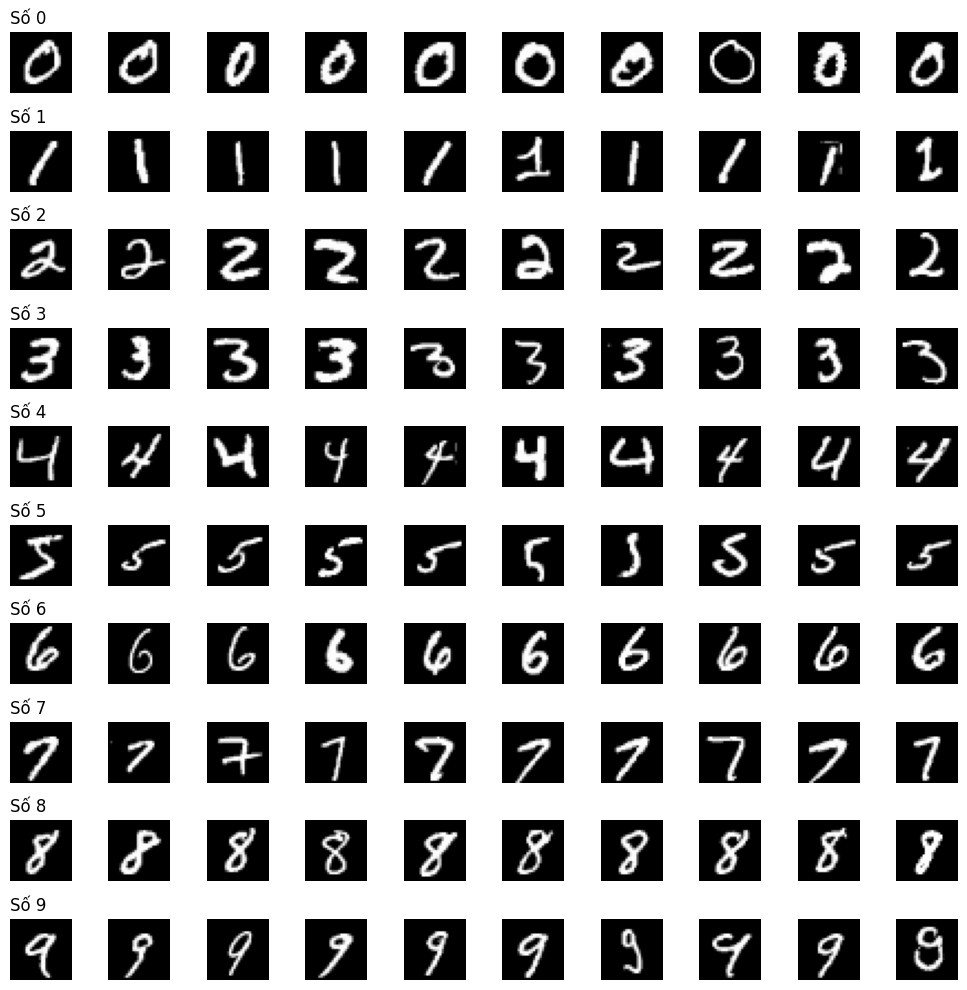

In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt
# 1. Load dataset MNIST

mnist = tf.keras.datasets.mnist

(x_train, y_train), (x_test, y_test) = mnist.load_data()

# 2. Kiểm tra kích thước

print("x_train:", x_train.shape)
print("y_train:", y_train.shape)

print("x_test:", x_test.shape)
print("y_test:", y_test.shape)

# 3. Kiểm tra pixel

print("Pixel nhỏ nhất:", x_train.min())
print("Pixel lớn nhất:", x_train.max())


# Hiển thị 10 ảnh cho mỗi chữ số từ 0 đến 9

fig, axes = plt.subplots(10, 10, figsize=(10, 10))

for digit in range(10):

    # Tìm tất cả vị trí có label bằng digit
    indices = (y_train == digit).nonzero()[0]

    # Lấy 10 ảnh đầu tiên của chữ số đó
    indices = indices[:10]

    for j, index in enumerate(indices):

        # Hiển thị ảnh
        axes[digit, j].imshow(x_train[index], cmap="gray")
        axes[digit, j].axis("off")
        if j == 0:
            axes[digit, j].set_title(f"Số {digit}", loc="left")

plt.tight_layout()
plt.show()

# Tiền xử lý dữ liệu

In [ ]:

# Chuẩn hóa pixel từ 0-255 về 0-1
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

In [ ]:
model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28, 28)),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dense(10, activation="softmax")
])

/usr/local/lib/python3.13/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


# Xây dựng model

In [ ]:
# Xây dựng model

model = tf.keras.Sequential([
    tf.keras.Input(shape=(28, 28)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128,activation="relu"),
    tf.keras.layers.Dense(10,activation="softmax")
])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Compile model

model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

In [ ]:
# Train model

history = model.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.9165 - loss: 0.2894 - val_accuracy: 0.9563 - val_loss: 0.1533
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 0.9629 - loss: 0.1263 - val_accuracy: 0.9665 - val_loss: 0.1140
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 19s 7ms/step - accuracy: 0.9738 - loss: 0.0870 - val_accuracy: 0.9691 - val_loss: 0.1026
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.9804 - loss: 0.0649 - val_accuracy: 0.9723 - val_loss: 0.0907
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9847 - loss: 0.0493 - val_accuracy: 0.9718 - val_loss: 0.0908
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9882 - loss: 0.0388 - val_accuracy: 0.9737 - val_loss: 0.0920
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.9911 - loss: 0.0299 - val_accuracy: 0.9758 - val_loss: 0.0897
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.9934 - loss: 0.

## Biểu đồ accuracy - loss

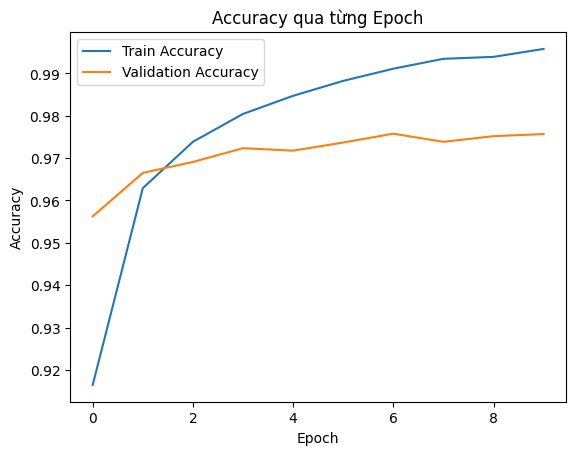

In [ ]:
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy qua từng Epoch")
plt.legend()

plt.show()

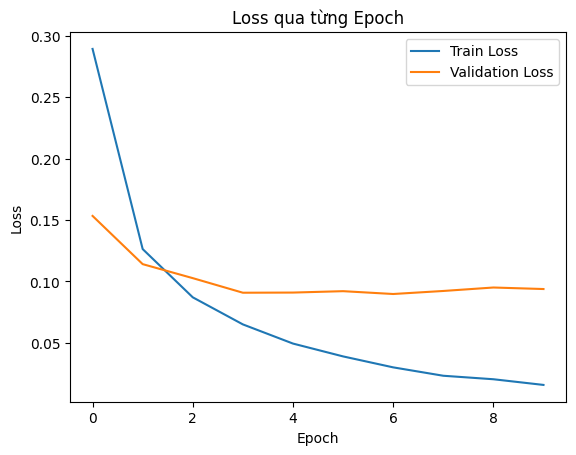

In [ ]:
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss qua từng Epoch")
plt.legend()

plt.show()

# Đánh giá

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9761 - loss: 0.0910
Test Loss: 0.0910
Test Accuracy: 97.61%
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


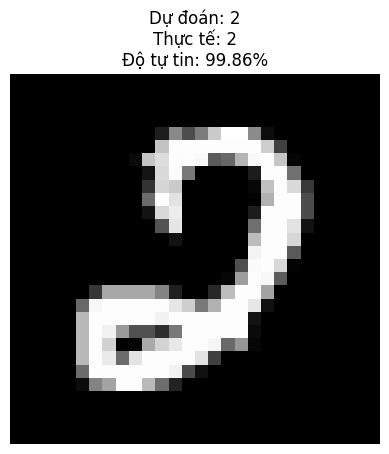

Số ảnh dự đoán sai: 239


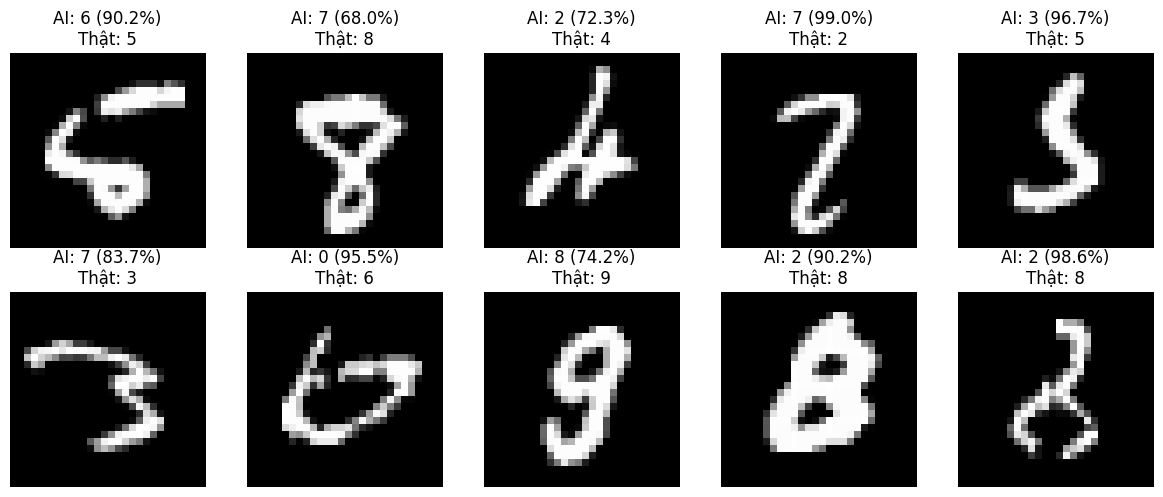

In [ ]:
test_loss, test_accuracy = model.evaluate(
    x_test,
    y_test
)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")


predictions = model.predict(x_test)
predicted_labels = predictions.argmax(axis=1)

index = 400

predicted_label = predicted_labels[index]
true_label = y_test[index]
confidence = predictions[index].max()

plt.imshow(x_test[index], cmap="gray")

plt.title(
    f"Dự đoán: {predicted_label}\n"
    f"Thực tế: {true_label}\n"
    f"Độ tự tin: {confidence * 100:.2f}%"
)

plt.axis("off")
plt.show()

wrong_indices = (predicted_labels != y_test).nonzero()[0]

print("Số ảnh dự đoán sai:", len(wrong_indices))

plt.figure(figsize=(12, 5))

for i in range(10):

    index = wrong_indices[i]

    predicted_label = predicted_labels[index]
    true_label = y_test[index]
    confidence = predictions[index].max()

    plt.subplot(2, 5, i + 1)

    plt.imshow(x_test[index], cmap="gray")

    plt.title(
        f"AI: {predicted_label} ({confidence * 100:.1f}%)\n"
        f"Thật: {true_label}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

# ảnh viết tay

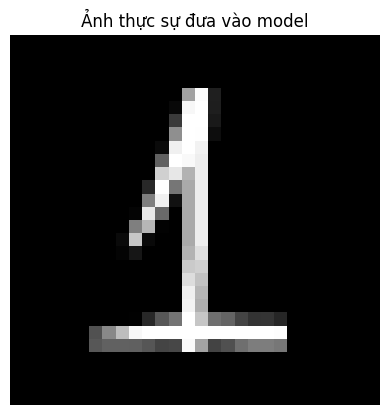

Shape: (28, 28)
Min: 0.0
Max: 1.0
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
AI dự đoán: 1
Độ tự tin: 100.00%
Số 0: 0.00%
Số 1: 100.00%
Số 2: 0.00%
Số 3: 0.00%
Số 4: 0.00%
Số 5: 0.00%
Số 6: 0.00%
Số 7: 0.00%
Số 8: 0.00%
Số 9: 0.00%


In [ ]:
filename = list(uploaded.keys())[0]

# Đọc ảnh
image = Image.open(filename).convert("L")
img = np.array(image)

# Nhị phân hóa ảnh
_, binary = cv2.threshold(img, 50, 255, cv2.THRESH_BINARY)

# Tìm các vùng sáng
contours, _ = cv2.findContours( binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Lấy contour lớn nhất -> chữ số
largest_contour = max(contours, key=cv2.contourArea)

x, y, w, h = cv2.boundingRect(largest_contour)

# Crop chỉ chữ số
digit = binary[y:y+h, x:x+w]

# Resize nhưng giữ tỷ lệ

height, width = digit.shape

if height > width:
    new_height = 20
    new_width = int(width * 20 / height)
else:
    new_width = 20
    new_height = int(height * 20 / width)

digit = cv2.resize(
    digit,
    (new_width, new_height),
    interpolation=cv2.INTER_AREA
)

# Đưa vào giữa canvas 28x28

canvas = np.zeros((28, 28), dtype=np.uint8)

x_offset = (28 - new_width) // 2
y_offset = (28 - new_height) // 2

canvas[
    y_offset:y_offset + new_height,
    x_offset:x_offset + new_width
] = digit

# Normalize
image_array = canvas.astype("float32") / 255.0

# Xem chính xác ảnh đưa vào AI
plt.imshow(image_array, cmap="gray")
plt.title("Ảnh thực sự đưa vào model")
plt.axis("off")
plt.show()

print("Shape:", image_array.shape)
print("Min:", image_array.min())
print("Max:", image_array.max())


image_input = np.expand_dims(image_array, axis=0)

prediction = model.predict(image_input)

predicted_digit = np.argmax(prediction[0])
confidence = np.max(prediction[0])

print("AI dự đoán:", predicted_digit)
print(f"Độ tự tin: {confidence * 100:.2f}%")

for i in range(10):
    print(f"Số {i}: {prediction[0][i] * 100:.2f}%")